In [6]:
## Imports
import time
import numpy as np
import glob
import matplotlib.pyplot as plt
import os
import fitsio as fio

from mocpy import WCS as MOCWCS
from mocpy import MOC
from pathlib import Path
from astropy import units as u
from astropy.coordinates import SkyCoord, Angle
from astropy.io import fits
from astropy.table import Table

In [ ]:
desi = fio.FITS(
    '/global/cfs/projectdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v1.1/nonKP/ELGnotqso_clustering.dat.fits'
    )
desi = desi[1].read(columns=['RA', 'DEC'])
coords_desi = SkyCoord(desi['RA'], desi['DEC'], unit='deg', frame='icrs')

hsc = fio.FITS(
    '/global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/data/hsc/cat/hscy3_cat.fits'
    )
hsc = hsc[1].read(columns=['RA', 'Dec'])
coords_hsc = SkyCoord(hsc['RA'], hsc['Dec'], unit='deg', frame='icrs')

moc_list = glob.glob(
    f'/global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/data/mocs/hsc_moc*.fits'
    )

Number of DESI targets in MOC: 416236
Number of HSC targets in MOC: 25260877
Number of DESI targets: 7809931
Percentage of DESI targets in MOC: 5.33%


Text(0.5, 1.0, 'HSC-DESI targets on MOCs')

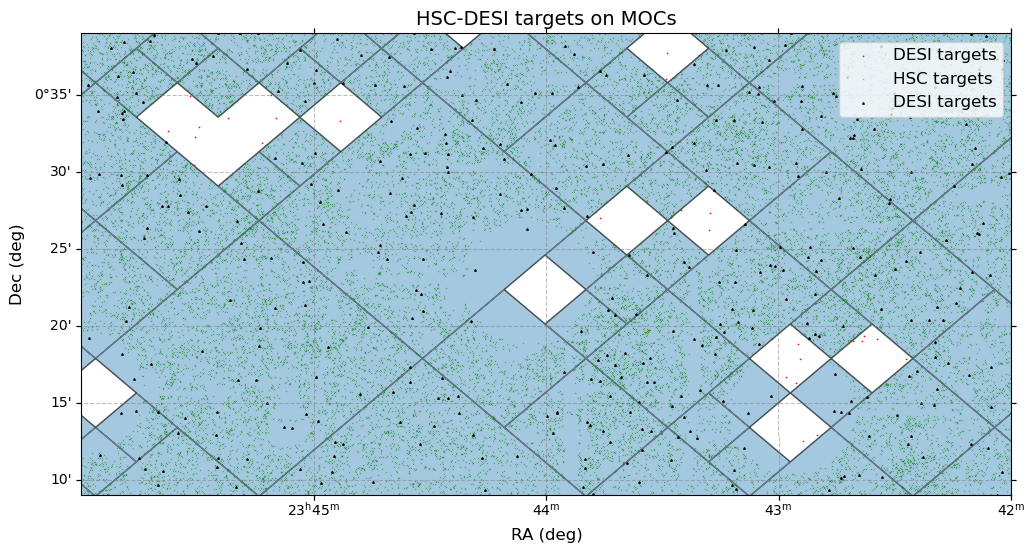

In [ ]:
fig = plt.figure(figsize=(12, 6))
with MOCWCS(fig,
           fov=0.5 * u.deg,
           center=SkyCoord(-4, 0.4, unit='deg', frame='icrs'),
           coordsys="icrs",
           rotation=Angle(0, u.degree),
           projection="AIT") as wcs: wcs = wcs
ax = fig.add_subplot(projection=wcs)

tr = ax.get_transform('world')

lon_hsc, lat_hsc = coords_hsc.ra.wrap_at(180 * u.deg).degree, coords_hsc.dec.degree
lon_desi, lat_desi = coords_desi.ra.wrap_at(180 * u.deg).degree, coords_desi.dec.degree

desi_in_moc_n = np.zeros(len(desi), dtype=bool)
for mocf in moc_list:
    moc = MOC.from_fits(mocf)
    desi_in_moc_n |= moc.contains_skycoords(coords_desi)
    moc.fill(ax=ax, wcs=wcs, alpha=0.4, fill=True)
    moc.border(ax=ax, wcs=wcs, alpha=0.4, color="black")

desi_in_moc = desi[np.flatnonzero(desi_in_moc_n)]
coords_desi_in_moc = SkyCoord(desi_in_moc['RA'], desi_in_moc['DEC'], unit='deg', frame='icrs')
lon_desi_in_moc, lat_desi_in_moc = coords_desi_in_moc.ra.wrap_at(180 * u.deg).degree, coords_desi_in_moc.dec.degree

print(f'Number of DESI targets in MOC: {len(desi_in_moc)}')
print(f'Number of HSC targets in MOC: {len(hsc)}')
print(f'Number of DESI targets: {len(desi)}')
print(f'Percentage of DESI targets in MOC: {len(desi_in_moc) / len(desi) * 100:.2f}%')

ax.scatter(
    lon_desi, 
    lat_desi,
    transform=tr,
    marker='v',
    s=0.05,
    color='red', 
    alpha=1,
    label='DESI targets'
    )

ax.scatter(
    lon_hsc, 
    lat_hsc,
    transform=tr,
    s=0.02, 
    marker='x',
    color='green', 
    alpha=0.7,
    label='HSC targets'
    )

ax.scatter(
    lon_desi_in_moc, 
    lat_desi_in_moc,
    transform=tr,
    marker='^',
    s=1,
    color='black', 
    alpha=1,
    label='DESI targets'
    )

ax.grid(color='gray', linestyle='--', alpha=0.5)
ax.legend(loc='upper right', fontsize=12)
ax.set_xlabel('RA (deg)', fontsize=12)
ax.set_ylabel('Dec (deg)', fontsize=12)
ax.set_title('HSC-DESI targets on MOCs', fontsize=14)

In [5]:
print(len(lon_desi_in_moc))

416236


In [ ]:
from desitarget.targetmask import desi_mask

desi_tgt = desi['DESI_TARGET']

is_bgs  = (desi_tgt & desi_mask.BGS_ANY != 0)   #- instead of 2**60
is_lrg  = (desi_tgt & desi_mask.LRG != 0)
is_elg  = (desi_tgt & desi_mask.ELG != 0)
is_qso  = (desi_tgt & desi_mask.QSO != 0)
is_mws  = (desi_tgt & desi_mask.MWS_ANY != 0)
is_scnd = (desi_tgt & desi_mask.SCND_ANY != 0)
masks = {
    'BGS': is_bgs,
    'LRG': is_lrg,
    'ELG': is_elg,
    'QSO': is_qso,
    #'MWS': is_mws,
    #'SCND': is_scnd
}
